# Training U-Net Blood Vessel Segmentation pada Dataset FIVES

Notebook ini melanjutkan notebook **Data Preparation FIVES** sebelumnya.

Target notebook:

1. Membaca file `processed_pairs.csv` dari Google Drive.
2. Membuat pipeline `tf.data` untuk train, validation, dan test.
3. Melatih model **U-Net** untuk segmentasi blood vessel.
4. Menyimpan model terbaik.
5. Mengevaluasi model pada test set.
6. Menyimpan predicted vessel mask, overlay, plot training, dan metrik evaluasi.

Struktur folder yang dipakai:

```text
/content/drive/MyDrive/BV_CDR/
├── splits/
│   └── processed_pairs.csv
├── processed/
│   ├── images_512/
│   └── masks_512/
├── models/
├── results/
└── predictions/
```

Notebook ini dibuat untuk **Google Colab GPU T4**. Kalau muncul error `OOM / out of memory`, turunkan `BATCH_SIZE` dari `4` menjadi `2` atau `1`.


In [ ]:
# ============================================================
# 1. Mount Google Drive
# ============================================================
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ============================================================
# 2. Cek GPU Colab
# ============================================================
import tensorflow as tf

print('TensorFlow version:', tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print('GPU terdeteksi:', gpus)

if len(gpus) == 0:
    print('WARNING: GPU belum aktif. Aktifkan melalui Runtime > Change runtime type > GPU.')
else:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as e:
            print('Memory growth tidak bisa diatur:', e)


TensorFlow version: 2.20.0
GPU terdeteksi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# 3. Import library utama
# ============================================================
import os
import json
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

print('Library berhasil diimport.')


Library berhasil diimport.


In [ ]:
# ============================================================
# 4. Konfigurasi path dan hyperparameter
# ============================================================
BASE_DIR = Path('/content/drive/MyDrive/BV_CDR')
CSV_PATH = BASE_DIR / 'splits' / 'processed_pairs.csv'

IMG_SIZE = 512
BATCH_SIZE = 4       # Jika OOM di T4, ubah menjadi 2 atau 1
EPOCHS = 50
LEARNING_RATE = 1e-4
RANDOM_SEED = 42

# Pilihan model: 'unet' atau 'attention_unet'
# Untuk model awal, gunakan 'unet' dulu agar stabil.
MODEL_TYPE = 'unet'

# Threshold untuk mengubah probabilitas menjadi mask binary
THRESHOLD = 0.5

# Jika True, data processed akan dicopy ke local runtime agar training lebih cepat.
# Kalau storage Colab penuh atau proses copy terlalu lama, ubah menjadi False.
USE_LOCAL_CACHE = True
LOCAL_CACHE_DIR = Path('/content/BV_CDR_cache')

MODEL_DIR = BASE_DIR / 'models' / MODEL_TYPE
RESULTS_DIR = BASE_DIR / 'results'
PLOTS_DIR = RESULTS_DIR / 'plots'
METRICS_DIR = RESULTS_DIR / 'metrics'
PREVIEW_DIR = RESULTS_DIR / 'previews' / 'training_fives'
PRED_DIR = BASE_DIR / 'predictions' / 'fives_test'
PRED_MASK_DIR = PRED_DIR / 'masks_pred'
PRED_OVERLAY_DIR = PRED_DIR / 'overlay'

for folder in [MODEL_DIR, PLOTS_DIR, METRICS_DIR, PREVIEW_DIR, PRED_MASK_DIR, PRED_OVERLAY_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / f'best_{MODEL_TYPE}_fives.keras'
LAST_MODEL_PATH = MODEL_DIR / f'last_{MODEL_TYPE}_fives.keras'
HISTORY_CSV_PATH = METRICS_DIR / f'history_{MODEL_TYPE}_fives.csv'
TEST_METRICS_CSV_PATH = METRICS_DIR / f'test_metrics_{MODEL_TYPE}_fives.csv'
PER_IMAGE_METRICS_CSV_PATH = METRICS_DIR / f'per_image_test_metrics_{MODEL_TYPE}_fives.csv'

print('BASE_DIR:', BASE_DIR)
print('CSV_PATH:', CSV_PATH)
print('MODEL_TYPE:', MODEL_TYPE)
print('BEST_MODEL_PATH:', BEST_MODEL_PATH)


BASE_DIR: /content/drive/MyDrive/BV_CDR
CSV_PATH: /content/drive/MyDrive/BV_CDR/splits/processed_pairs.csv
MODEL_TYPE: unet
BEST_MODEL_PATH: /content/drive/MyDrive/BV_CDR/models/unet/best_unet_fives.keras


In [ ]:
# ============================================================
# 5. Reproducibility seed
# ============================================================
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('Seed diset ke:', RANDOM_SEED)


Seed diset ke: 42


In [ ]:
# ============================================================
# 6. Baca processed_pairs.csv
# ============================================================
assert CSV_PATH.exists(), f'File tidak ditemukan: {CSV_PATH}. Jalankan notebook data preparation dulu.'

df = pd.read_csv(CSV_PATH)
required_cols = {'filename', 'split', 'image_path', 'mask_path'}
assert required_cols.issubset(df.columns), f'Kolom CSV harus berisi: {required_cols}'

print('Jumlah total data:', len(df))
print(df['split'].value_counts())
display(df.head())


Jumlah total data: 400
split
train    279
test      61
val       60
Name: count, dtype: int64


,filename,split,image_path,mask_path
0,FIVES-1,test,/content/drive/MyDrive/BV_CDR/processed/images...,/content/drive/MyDrive/BV_CDR/processed/masks_...
1,FIVES-103,test,/content/drive/MyDrive/BV_CDR/processed/images...,/content/drive/MyDrive/BV_CDR/processed/masks_...
2,FIVES-107,test,/content/drive/MyDrive/BV_CDR/processed/images...,/content/drive/MyDrive/BV_CDR/processed/masks_...
3,FIVES-121,test,/content/drive/MyDrive/BV_CDR/processed/images...,/content/drive/MyDrive/BV_CDR/processed/masks_...
4,FIVES-127,test,/content/drive/MyDrive/BV_CDR/processed/images...,/content/drive/MyDrive/BV_CDR/processed/masks_...


In [ ]:
# ============================================================
# 7. Optional: copy processed data ke local runtime agar training lebih cepat
# ============================================================
if USE_LOCAL_CACHE:
    print('Menyalin folder processed ke local runtime. Ini bisa memakan beberapa menit...')
    src_processed = BASE_DIR / 'processed'
    dst_processed = LOCAL_CACHE_DIR / 'processed'
    dst_processed.parent.mkdir(parents=True, exist_ok=True)

    assert src_processed.exists(), f'Folder processed tidak ditemukan: {src_processed}'
    shutil.copytree(src_processed, dst_processed, dirs_exist_ok=True)

    # Ubah path CSV dari Google Drive ke local cache.
    df_cached = df.copy()
    df_cached['image_path'] = df_cached['image_path'].astype(str).str.replace(
        str(src_processed), str(dst_processed), regex=False
    )
    df_cached['mask_path'] = df_cached['mask_path'].astype(str).str.replace(
        str(src_processed), str(dst_processed), regex=False
    )

    df = df_cached
    print('Data berhasil dicopy ke:', dst_processed)
else:
    print('USE_LOCAL_CACHE = False. Data akan dibaca langsung dari Google Drive.')

# Cek beberapa path setelah cache
for idx, row in df.head(3).iterrows():
    assert Path(row['image_path']).exists(), f"Image tidak ditemukan: {row['image_path']}"
    assert Path(row['mask_path']).exists(), f"Mask tidak ditemukan: {row['mask_path']}"

print('Cek path image dan mask aman.')


Menyalin folder processed ke local runtime. Ini bisa memakan beberapa menit...
Data berhasil dicopy ke: /content/BV_CDR_cache/processed
Cek path image dan mask aman.


In [ ]:
# ============================================================
# 8. Pisahkan dataframe train, val, test
# ============================================================
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df = df[df['split'] == 'val'].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)

print('Train:', len(train_df))
print('Val  :', len(val_df))
print('Test :', len(test_df))

assert len(train_df) > 0, 'Train set kosong.'
assert len(val_df) > 0, 'Validation set kosong.'
assert len(test_df) > 0, 'Test set kosong.'


Train: 279
Val  : 60
Test : 61


In [ ]:
# ============================================================
# 9. Fungsi load image-mask untuk tf.data
# ============================================================
def read_image_mask(image_path, mask_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], method='bilinear')
    image = tf.cast(image, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE], method='nearest')
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0)

    return image, mask


def augment_image_mask(image, mask):
    # Flip horizontal
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # Flip vertical
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    # Brightness dan contrast hanya untuk image, bukan mask
    image = tf.image.random_brightness(image, max_delta=0.08)
    image = tf.image.random_contrast(image, lower=0.90, upper=1.10)
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, mask


def make_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False, augment=False):
    image_paths = dataframe['image_path'].astype(str).values
    mask_paths = dataframe['mask_path'].astype(str).values

    ds = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=RANDOM_SEED, reshuffle_each_iteration=True)

    ds = ds.map(read_image_mask, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        ds = ds.map(augment_image_mask, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True, augment=True)
val_ds = make_dataset(val_df, shuffle=False, augment=False)
test_ds = make_dataset(test_df, shuffle=False, augment=False)

print('tf.data pipeline siap.')


tf.data pipeline siap.


Image batch shape: (4, 512, 512, 3)
Mask batch shape : (4, 512, 512, 1)


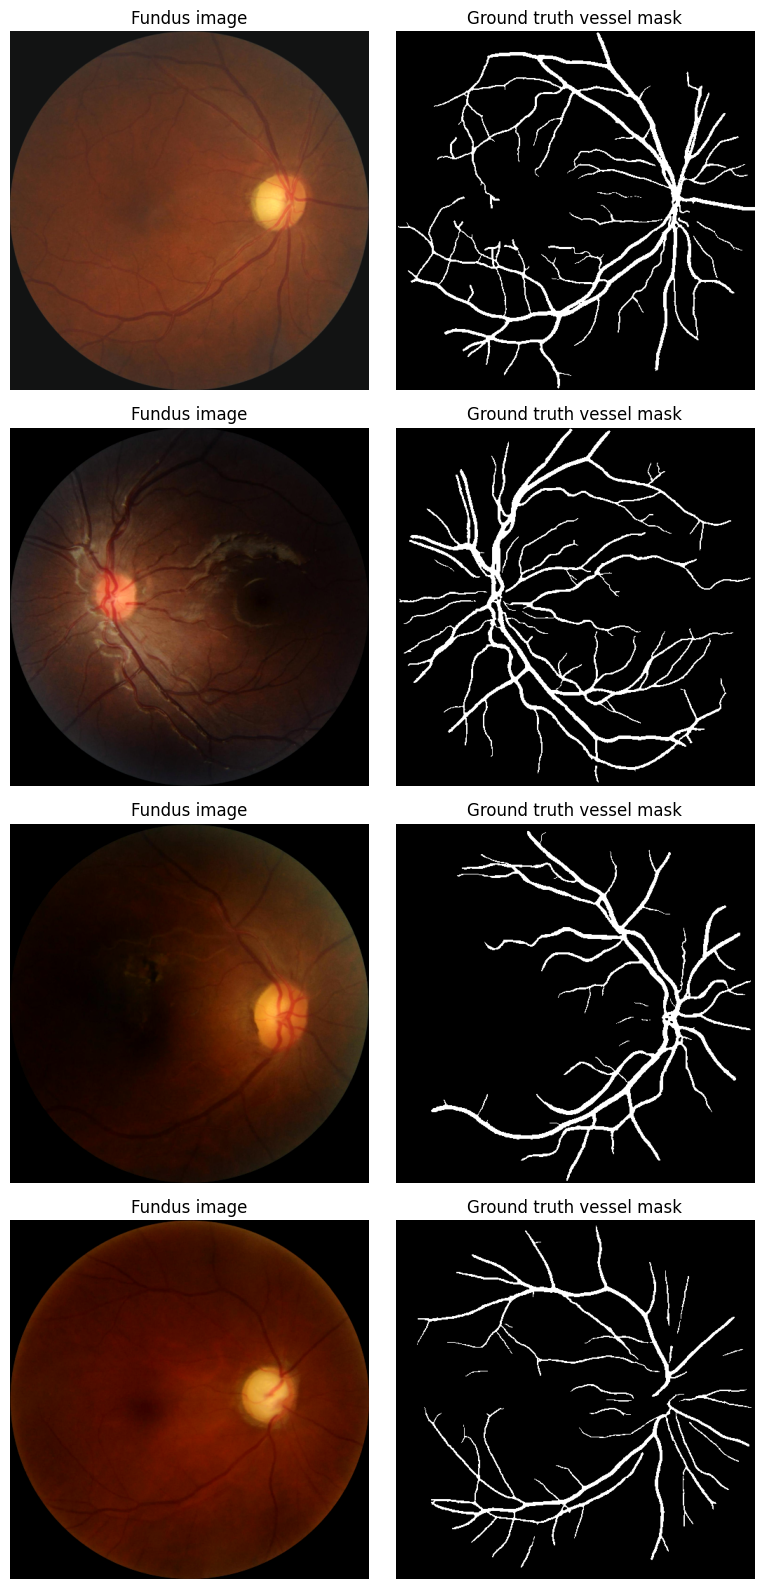

In [ ]:
# ============================================================
# 10. Preview batch training
# ============================================================
for images, masks in train_ds.take(1):
    print('Image batch shape:', images.shape)
    print('Mask batch shape :', masks.shape)

    n_show = min(4, images.shape[0])
    fig, axes = plt.subplots(n_show, 2, figsize=(8, 4 * n_show))

    if n_show == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n_show):
        axes[i, 0].imshow(images[i].numpy())
        axes[i, 0].set_title('Fundus image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(masks[i, :, :, 0].numpy(), cmap='gray')
        axes[i, 1].set_title('Ground truth vessel mask')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
# ============================================================
# 11. Metric dan loss function
# ============================================================
SMOOTH = 1e-6


def dice_coef(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    denominator = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    return (2.0 * intersection + SMOOTH) / (denominator + SMOOTH)


def iou_coef(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + SMOOTH) / (union + SMOOTH)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


bce = tf.keras.losses.BinaryCrossentropy()


def bce_dice_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)


def specificity_metric(y_true, y_pred):
    y_true = tf.cast(y_true > 0.5, tf.float32)
    y_pred = tf.cast(y_pred > THRESHOLD, tf.float32)

    tn = tf.reduce_sum((1.0 - y_true) * (1.0 - y_pred))
    fp = tf.reduce_sum((1.0 - y_true) * y_pred)

    return (tn + SMOOTH) / (tn + fp + SMOOTH)

print('Loss dan metric siap.')


Loss dan metric siap.


In [ ]:
# ============================================================
# 12. Arsitektur U-Net dan Attention U-Net
# ============================================================
def conv_block(x, filters, name=None):
    x = layers.Conv2D(filters, 3, padding='same', kernel_initializer='he_normal', name=None if name is None else f'{name}_conv1')(x)
    x = layers.BatchNormalization(name=None if name is None else f'{name}_bn1')(x)
    x = layers.Activation('relu', name=None if name is None else f'{name}_relu1')(x)

    x = layers.Conv2D(filters, 3, padding='same', kernel_initializer='he_normal', name=None if name is None else f'{name}_conv2')(x)
    x = layers.BatchNormalization(name=None if name is None else f'{name}_bn2')(x)
    x = layers.Activation('relu', name=None if name is None else f'{name}_relu2')(x)
    return x


def encoder_block(x, filters, name=None):
    c = conv_block(x, filters, name=name)
    p = layers.MaxPooling2D((2, 2), name=None if name is None else f'{name}_pool')(c)
    return c, p


def decoder_block(x, skip, filters, name=None):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same', name=None if name is None else f'{name}_up')(x)
    x = layers.Concatenate(name=None if name is None else f'{name}_concat')([x, skip])
    x = conv_block(x, filters, name=name)
    return x


def attention_gate(skip, gating, filters, name=None):
    theta_x = layers.Conv2D(filters, 1, padding='same', name=None if name is None else f'{name}_theta_x')(skip)
    phi_g = layers.Conv2D(filters, 1, padding='same', name=None if name is None else f'{name}_phi_g')(gating)

    add = layers.Add(name=None if name is None else f'{name}_add')([theta_x, phi_g])
    act = layers.Activation('relu', name=None if name is None else f'{name}_relu')(add)
    psi = layers.Conv2D(1, 1, padding='same', name=None if name is None else f'{name}_psi')(act)
    alpha = layers.Activation('sigmoid', name=None if name is None else f'{name}_sigmoid')(psi)

    out = layers.Multiply(name=None if name is None else f'{name}_multiply')([skip, alpha])
    return out


def attention_decoder_block(x, skip, filters, name=None):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same', name=None if name is None else f'{name}_up')(x)
    attn_skip = attention_gate(skip, x, filters, name=None if name is None else f'{name}_attn')
    x = layers.Concatenate(name=None if name is None else f'{name}_concat')([x, attn_skip])
    x = conv_block(x, filters, name=name)
    return x


def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), base_filters=32):
    inputs = layers.Input(input_shape)

    s1, p1 = encoder_block(inputs, base_filters, name='enc1')
    s2, p2 = encoder_block(p1, base_filters * 2, name='enc2')
    s3, p3 = encoder_block(p2, base_filters * 4, name='enc3')
    s4, p4 = encoder_block(p3, base_filters * 8, name='enc4')

    b1 = conv_block(p4, base_filters * 16, name='bottleneck')

    d1 = decoder_block(b1, s4, base_filters * 8, name='dec1')
    d2 = decoder_block(d1, s3, base_filters * 4, name='dec2')
    d3 = decoder_block(d2, s2, base_filters * 2, name='dec3')
    d4 = decoder_block(d3, s1, base_filters, name='dec4')

    outputs = layers.Conv2D(1, 1, padding='same', activation='sigmoid', dtype='float32', name='vessel_mask')(d4)
    model = models.Model(inputs, outputs, name='UNet_FIVES_Vessel')
    return model


def build_attention_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), base_filters=32):
    inputs = layers.Input(input_shape)

    s1, p1 = encoder_block(inputs, base_filters, name='enc1')
    s2, p2 = encoder_block(p1, base_filters * 2, name='enc2')
    s3, p3 = encoder_block(p2, base_filters * 4, name='enc3')
    s4, p4 = encoder_block(p3, base_filters * 8, name='enc4')

    b1 = conv_block(p4, base_filters * 16, name='bottleneck')

    d1 = attention_decoder_block(b1, s4, base_filters * 8, name='dec1')
    d2 = attention_decoder_block(d1, s3, base_filters * 4, name='dec2')
    d3 = attention_decoder_block(d2, s2, base_filters * 2, name='dec3')
    d4 = attention_decoder_block(d3, s1, base_filters, name='dec4')

    outputs = layers.Conv2D(1, 1, padding='same', activation='sigmoid', dtype='float32', name='vessel_mask')(d4)
    model = models.Model(inputs, outputs, name='Attention_UNet_FIVES_Vessel')
    return model


if MODEL_TYPE == 'unet':
    model = build_unet()
elif MODEL_TYPE == 'attention_unet':
    model = build_attention_unet()
else:
    raise ValueError("MODEL_TYPE harus 'unet' atau 'attention_unet'")

model.summary()


Model: "UNet_FIVES_Vessel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv1 (Conv2D) │ (None, 512, 512,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, 512, 512,  │        128 │ enc1_conv1[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu1          │ (None, 512, 512,  │          0 │ enc1_bn1[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv2 (Conv2D) │ (None, 512, 512,  │      9,248 │ enc1_relu1[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn2            │ (None, 512, 512,  │        128 │ enc1_conv2[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu2          │ (None, 512, 512,  │          0 │ enc1_bn2[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_pool           │ (None, 256, 256,  │          0 │ enc1_relu2[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv1 (Conv2D) │ (None, 256, 256,  │     18,496 │ enc1_pool[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn1            │ (None, 256, 256,  │        256 │ enc2_conv1[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_relu1          │ (None, 256, 256,  │          0 │ enc2_bn1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv2 (Conv2D) │ (None, 256, 256,  │     36,928 │ enc2_relu1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn2            │ (None, 256, 256,  │        256 │ enc2_conv2[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_relu2          │ (None, 256, 256,  │          0 │ enc2_bn2[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_pool           │ (None, 128, 128,  │          0 │ enc2_relu2[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_conv1 (Conv2D) │ (None, 128, 128,  │     73,856 │ enc2_pool[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn1            │ (None, 128, 128,  │        512 │ enc3_conv1[0][0]

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [ ]:
# ============================================================
# 13. Compile model
# ============================================================
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss=bce_dice_loss,
    metrics=[
        dice_coef,
        iou_coef,
        tf.keras.metrics.BinaryAccuracy(name='binary_accuracy', threshold=THRESHOLD),
        tf.keras.metrics.Precision(name='precision', thresholds=THRESHOLD),
        tf.keras.metrics.Recall(name='recall', thresholds=THRESHOLD),
        specificity_metric,
    ]
)

print('Model berhasil dicompile.')


Model berhasil dicompile.


In [ ]:
# ============================================================
# 14. Callback training
# ============================================================
callbacks = [
    ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor='val_dice_coef',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1,
    ),
    EarlyStopping(
        monitor='val_dice_coef',
        mode='max',
        patience=12,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        mode='min',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    CSVLogger(str(HISTORY_CSV_PATH)),
]

print('Callback siap.')


Callback siap.


In [ ]:
# ============================================================
# 15. Training model
# ============================================================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

model.save(LAST_MODEL_PATH)
print('Training selesai.')
print('Best model:', BEST_MODEL_PATH)
print('Last model:', LAST_MODEL_PATH)
print('History CSV:', HISTORY_CSV_PATH)


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 993ms/step - binary_accuracy: 0.5471 - dice_coef: 0.1498 - iou_coef: 0.0811 - loss: 1.6189 - precision: 0.1052 - recall: 0.6147 - specificity_metric: 0.5417
Epoch 1: val_dice_coef improved from None to 0.13879, saving model to /content/drive/MyDrive/BV_CDR/models/unet/best_unet_fives.keras

Epoch 1: finished saving model to /content/drive/MyDrive/BV_CDR/models/unet/best_unet_fives.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - binary_accuracy: 0.6947 - dice_coef: 0.1606 - iou_coef: 0.0874 - loss: 1.4819 - precision: 0.1338 - recall: 0.5294 - specificity_metric: 0.7098 - val_binary_accuracy: 0.9091 - val_dice_coef: 0.1388 - val_iou_coef: 0.0747 - val_loss: 1.4725 - val_precision: 0.2408 - val_recall: 0.0675 - val_specificity_metric: 0.9817 - learning_rate: 1.0000e-04
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - binary_accuracy: 0.9070 - dice_coef: 0.1866 - iou_coef: 0.1031 - loss: 1.2512 - precision: 0.4017 - recall: 0.3425 - specificit

,binary_accuracy,dice_coef,iou_coef,loss,precision,recall,specificity_metric,val_binary_accuracy,val_dice_coef,val_iou_coef,val_loss,val_precision,val_recall,val_specificity_metric,learning_rate
45,0.987243,0.870255,0.771192,0.173157,0.929663,0.905617,0.994190,0.986336,0.869852,0.770141,0.176782,0.914907,0.912745,0.992672,0.0001
46,0.987363,0.873179,0.775405,0.169396,0.929965,0.906931,0.994193,0.986667,0.868768,0.768411,0.176208,0.948430,0.879875,0.995870,0.0001
47,0.987369,0.874957,0.778270,0.167683,0.931827,0.904913,0.994375,0.987008,0.874438,0.777350,0.168920,0.931446,0.902773,0.994267,0.0001
48,0.987818,0.879146,0.784971,0.161863,0.933373,0.909349,0.994486,0.986985,0.874528,0.777498,0.168561,0.941892,0.891008,0.995258,0.0001
49,0.987710,0.880575,0.787183,0.160852,0.933648,0.907559,0.994520,0.986430,0.877819,0.782672,0.166549,0.909043,0.921219,0.992045,0.0001


Plot disimpan: /content/drive/MyDrive/BV_CDR/results/plots/loss_curve_unet.png


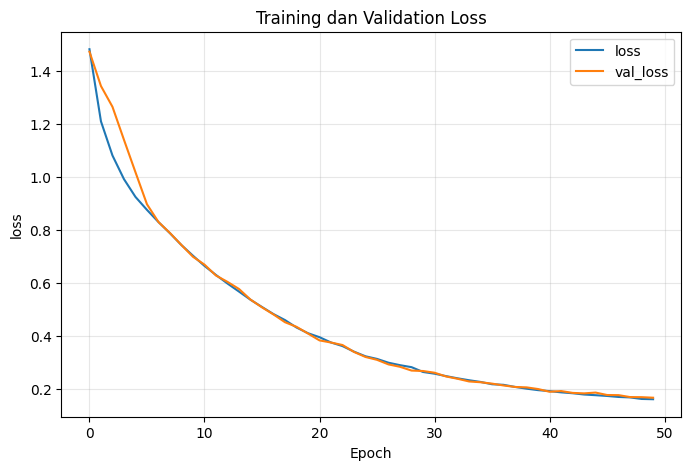

Plot disimpan: /content/drive/MyDrive/BV_CDR/results/plots/dice_curve_unet.png


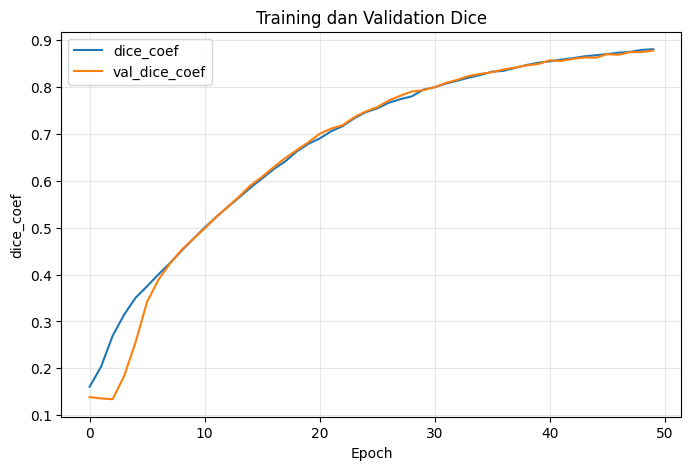

Plot disimpan: /content/drive/MyDrive/BV_CDR/results/plots/iou_curve_unet.png


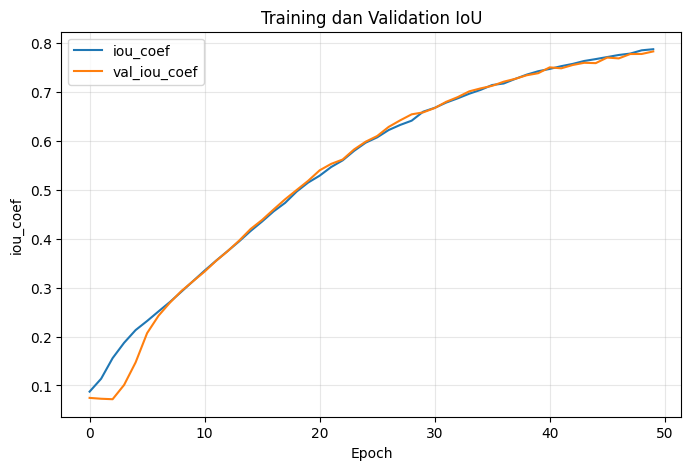

In [ ]:
# ============================================================
# 16. Plot kurva training
# ============================================================
history_df = pd.DataFrame(history.history)
display(history_df.tail())

# Simpan ulang history untuk memastikan ada file terbaru
history_df.to_csv(HISTORY_CSV_PATH, index=False)


def plot_history(metric_name, val_metric_name=None, title=None, save_name=None):
    if val_metric_name is None:
        val_metric_name = 'val_' + metric_name

    plt.figure(figsize=(8, 5))
    if metric_name in history_df.columns:
        plt.plot(history_df[metric_name], label=metric_name)
    if val_metric_name in history_df.columns:
        plt.plot(history_df[val_metric_name], label=val_metric_name)

    plt.xlabel('Epoch')
    plt.ylabel(metric_name)
    plt.title(title if title is not None else metric_name)
    plt.legend()
    plt.grid(True, alpha=0.3)

    if save_name is not None:
        save_path = PLOTS_DIR / save_name
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print('Plot disimpan:', save_path)

    plt.show()

plot_history('loss', 'val_loss', title='Training dan Validation Loss', save_name=f'loss_curve_{MODEL_TYPE}.png')
plot_history('dice_coef', 'val_dice_coef', title='Training dan Validation Dice', save_name=f'dice_curve_{MODEL_TYPE}.png')
plot_history('iou_coef', 'val_iou_coef', title='Training dan Validation IoU', save_name=f'iou_curve_{MODEL_TYPE}.png')


In [ ]:
# ============================================================
# 17. Load best model dan evaluasi pada test set
# ============================================================
custom_objects = {
    'bce_dice_loss': bce_dice_loss,
    'dice_loss': dice_loss,
    'dice_coef': dice_coef,
    'iou_coef': iou_coef,
    'specificity_metric': specificity_metric,
}

best_model = tf.keras.models.load_model(BEST_MODEL_PATH, custom_objects=custom_objects)

test_results = best_model.evaluate(test_ds, verbose=1)
metric_names = best_model.metrics_names

test_metrics = dict(zip(metric_names, test_results))
test_metrics['model_type'] = MODEL_TYPE
test_metrics['img_size'] = IMG_SIZE
test_metrics['batch_size'] = BATCH_SIZE
test_metrics['threshold'] = THRESHOLD

test_metrics_df = pd.DataFrame([test_metrics])
test_metrics_df.to_csv(TEST_METRICS_CSV_PATH, index=False)

display(test_metrics_df)
print('Test metrics disimpan di:', TEST_METRICS_CSV_PATH)


16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 719ms/step - binary_accuracy: 0.9864 - dice_coef: 0.8772 - iou_coef: 0.7820 - loss: 0.1683 - precision: 0.9081 - recall: 0.9214 - specificity_metric: 0.9920


,loss,compile_metrics,model_type,img_size,batch_size,threshold
0,0.168318,0.877249,unet,512,4,0.5


Test metrics disimpan di: /content/drive/MyDrive/BV_CDR/results/metrics/test_metrics_unet_fives.csv


In [ ]:
# ============================================================
# 18. Fungsi prediksi satu gambar dan hitung metrik pixel-level
# ============================================================
def load_image_np(path):
    image = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.Resampling.BILINEAR)
    image_np = np.array(image).astype(np.float32) / 255.0
    return image_np


def load_mask_np(path):
    mask = Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE), Image.Resampling.NEAREST)
    mask_np = np.array(mask)
    mask_bin = (mask_np > 127).astype(np.uint8)
    return mask_bin


def predict_mask(model, image_np, threshold=THRESHOLD):
    pred_prob = model.predict(np.expand_dims(image_np, axis=0), verbose=0)[0, :, :, 0]
    pred_bin = (pred_prob >= threshold).astype(np.uint8)
    return pred_prob, pred_bin


def compute_binary_metrics(y_true, y_pred):
    y_true = y_true.astype(np.uint8).reshape(-1)
    y_pred = y_pred.astype(np.uint8).reshape(-1)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)

    return {
        'tp': int(tp),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'accuracy': accuracy,
        'precision': precision,
        'recall_sensitivity': recall,
        'specificity': specificity,
        'f1_score': f1,
        'dice': dice,
        'iou': iou,
    }


def make_overlay_np(image_np, mask_bin, alpha=0.45):
    image_uint8 = (image_np * 255).astype(np.uint8)
    overlay = image_uint8.copy()
    vessel = mask_bin > 0

    # Overlay merah untuk area vessel prediksi.
    overlay[vessel, 0] = 255
    overlay[vessel, 1] = (overlay[vessel, 1] * (1 - alpha)).astype(np.uint8)
    overlay[vessel, 2] = (overlay[vessel, 2] * (1 - alpha)).astype(np.uint8)

    blended = (image_uint8 * (1 - alpha) + overlay * alpha).clip(0, 255).astype(np.uint8)
    return blended

print('Fungsi prediksi dan metrik siap.')


Fungsi prediksi dan metrik siap.


In [ ]:
# ============================================================
# 19. Prediksi semua test set dan simpan predicted mask + overlay
# ============================================================
per_image_records = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Predicting test set'):
    filename = row['filename']
    image_np = load_image_np(row['image_path'])
    true_mask = load_mask_np(row['mask_path'])

    pred_prob, pred_bin = predict_mask(best_model, image_np, THRESHOLD)
    metrics = compute_binary_metrics(true_mask, pred_bin)

    pred_mask_uint8 = (pred_bin * 255).astype(np.uint8)
    overlay = make_overlay_np(image_np, pred_bin)

    pred_mask_path = PRED_MASK_DIR / f'{filename}_pred.png'
    overlay_path = PRED_OVERLAY_DIR / f'{filename}_overlay.png'

    Image.fromarray(pred_mask_uint8).save(pred_mask_path)
    Image.fromarray(overlay).save(overlay_path)

    record = {
        'filename': filename,
        'image_path': row['image_path'],
        'gt_mask_path': row['mask_path'],
        'pred_mask_path': str(pred_mask_path),
        'overlay_path': str(overlay_path),
    }
    record.update(metrics)
    per_image_records.append(record)

per_image_df = pd.DataFrame(per_image_records)
per_image_df.to_csv(PER_IMAGE_METRICS_CSV_PATH, index=False)

print('Prediksi test set selesai.')
print('Predicted masks:', PRED_MASK_DIR)
print('Overlay:', PRED_OVERLAY_DIR)
print('Per-image metrics:', PER_IMAGE_METRICS_CSV_PATH)
display(per_image_df.head())


Predicting test set:   0%|          | 0/61 [00:00<?, ?it/s]

Prediksi test set selesai.
Predicted masks: /content/drive/MyDrive/BV_CDR/predictions/fives_test/masks_pred
Overlay: /content/drive/MyDrive/BV_CDR/predictions/fives_test/overlay
Per-image metrics: /content/drive/MyDrive/BV_CDR/results/metrics/per_image_test_metrics_unet_fives.csv


,filename,image_path,gt_mask_path,pred_mask_path,overlay_path,tp,tn,fp,fn,accuracy,precision,recall_sensitivity,specificity,f1_score,dice,iou
0,FIVES-1,/content/BV_CDR_cache/processed/images_512/tes...,/content/BV_CDR_cache/processed/masks_512/test...,/content/drive/MyDrive/BV_CDR/predictions/five...,/content/drive/MyDrive/BV_CDR/predictions/five...,12033,246902,1184,2025,0.987759,0.910418,0.855954,0.995227,0.882346,0.882346,0.789463
1,FIVES-103,/content/BV_CDR_cache/processed/images_512/tes...,/content/BV_CDR_cache/processed/masks_512/test...,/content/drive/MyDrive/BV_CDR/predictions/five...,/content/drive/MyDrive/BV_CDR/predictions/five...,28171,230422,2451,1100,0.986454,0.919960,0.962420,0.989475,0.940711,0.940711,0.888059
2,FIVES-107,/content/BV_CDR_cache/processed/images_512/tes...,/content/BV_CDR_cache/processed/masks_512/test...,/content/drive/MyDrive/BV_CDR/predictions/five...,/content/drive/MyDrive/BV_CDR/predictions/five...,12004,247193,1672,1275,0.988758,0.877742,0.903984,0.993281,0.890670,0.890670,0.802889
3,FIVES-121,/content/BV_CDR_cache/processed/images_512/tes...,/content/BV_CDR_cache/processed/masks_512/test...,/content/drive/MyDrive/BV_CDR/predictions/five...,/content/drive/MyDrive/BV_CDR/predictions/five...,22339,235641,2274,1890,0.984116,0.907610,0.921994,0.990442,0.914746,0.914746,0.842886
4,FIVES-127,/content/BV_CDR_cache/processed/images_512/tes...,/content/BV_CDR_cache/processed/masks_512/test...,/content/drive/MyDrive/BV_CDR/predictions/five...,/content/drive/MyDrive/BV_CDR/predictions/five...,15376,243623,2099,1046,0.988003,0.879886,0.936305,0.991458,0.907219,0.907219,0.830193


In [ ]:
# ============================================================
# 20. Ringkasan metrik pixel-level test set
# ============================================================
metric_cols = ['accuracy', 'precision', 'recall_sensitivity', 'specificity', 'f1_score', 'dice', 'iou']
summary_metrics = per_image_df[metric_cols].agg(['mean', 'std', 'min', 'max']).T.reset_index()
summary_metrics = summary_metrics.rename(columns={'index': 'metric'})

summary_path = METRICS_DIR / f'summary_pixel_metrics_{MODEL_TYPE}_fives.csv'
summary_metrics.to_csv(summary_path, index=False)

display(summary_metrics)
print('Ringkasan pixel-level metrics disimpan di:', summary_path)


,metric,mean,std,min,max
0,accuracy,0.986399,0.003293,0.976524,0.991493
1,precision,0.903149,0.032979,0.805556,0.950038
2,recall_sensitivity,0.912404,0.051643,0.677972,0.985147
3,specificity,0.991956,0.002793,0.981073,0.996118
4,f1_score,0.907158,0.037190,0.736277,0.947329
5,dice,0.907158,0.037190,0.736277,0.947329
6,iou,0.832048,0.058569,0.582626,0.899930


Ringkasan pixel-level metrics disimpan di: /content/drive/MyDrive/BV_CDR/results/metrics/summary_pixel_metrics_unet_fives.csv


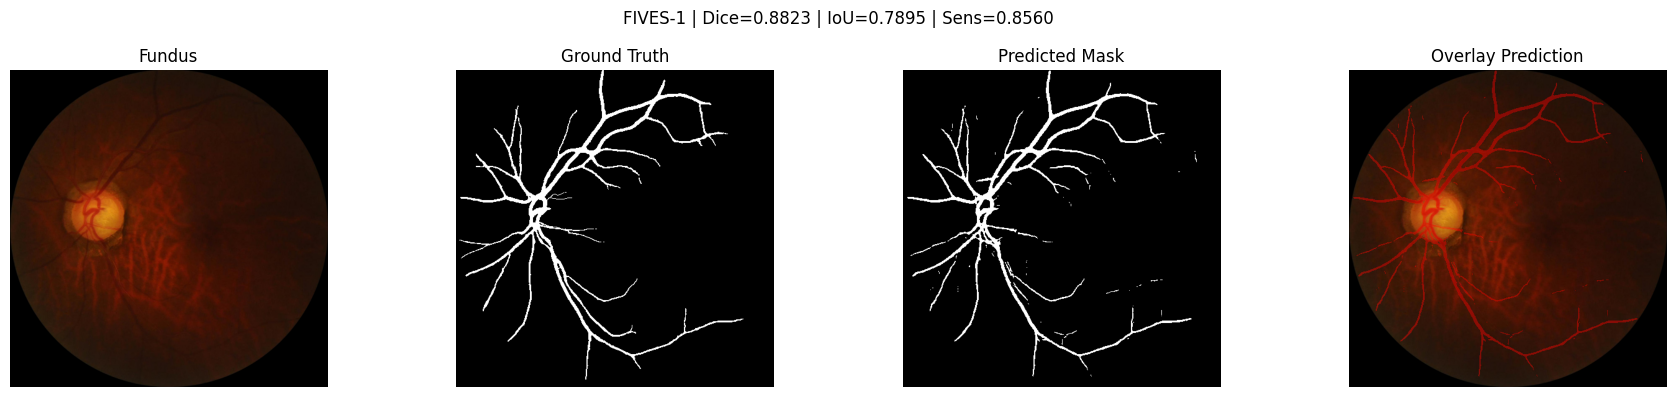

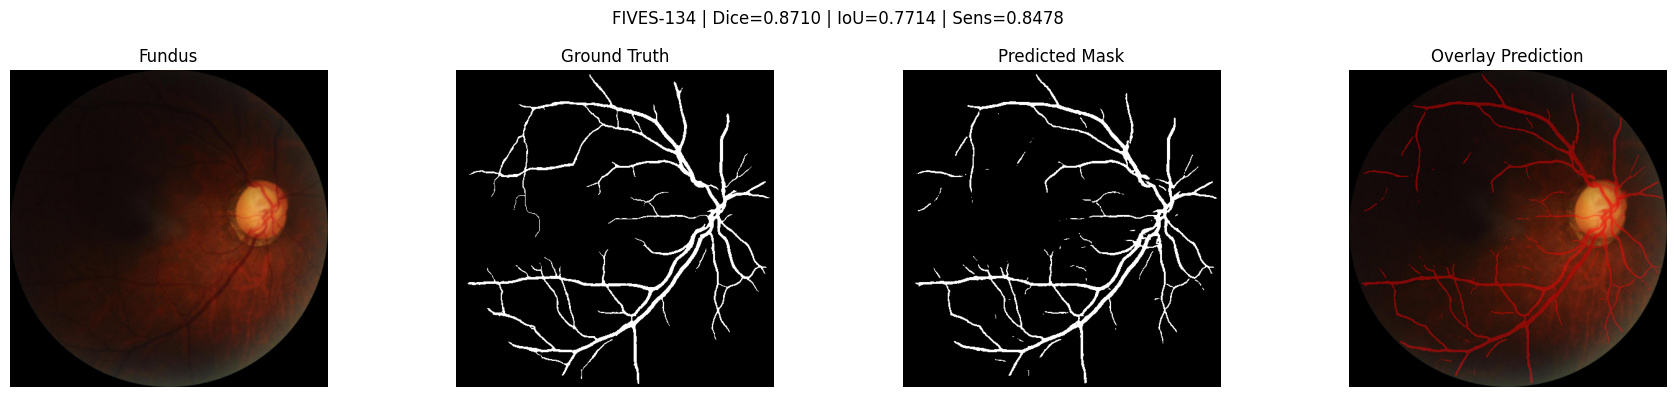

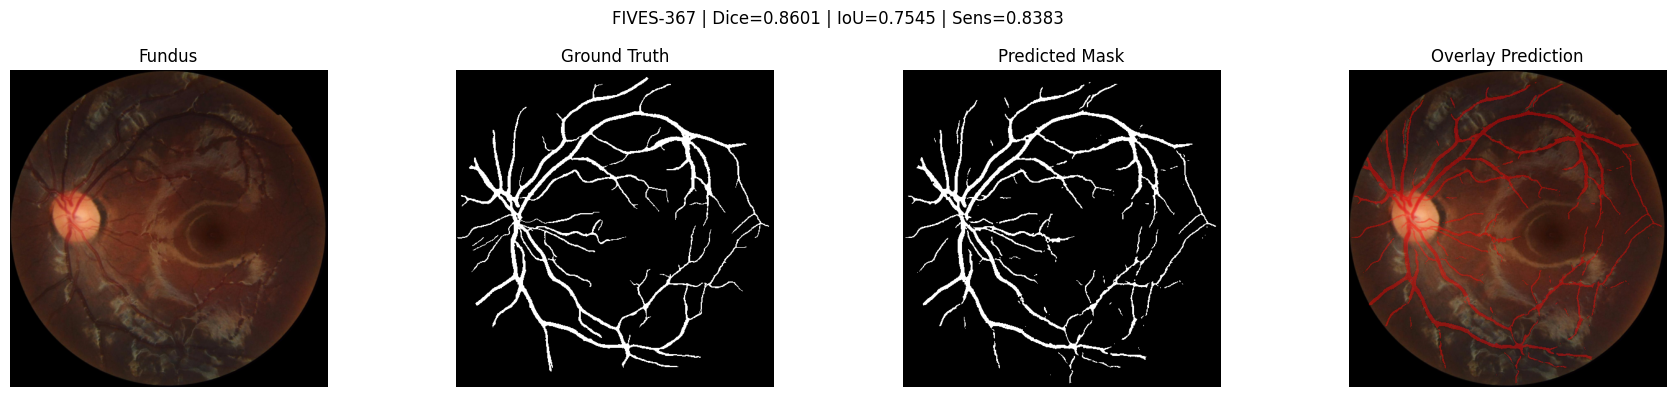

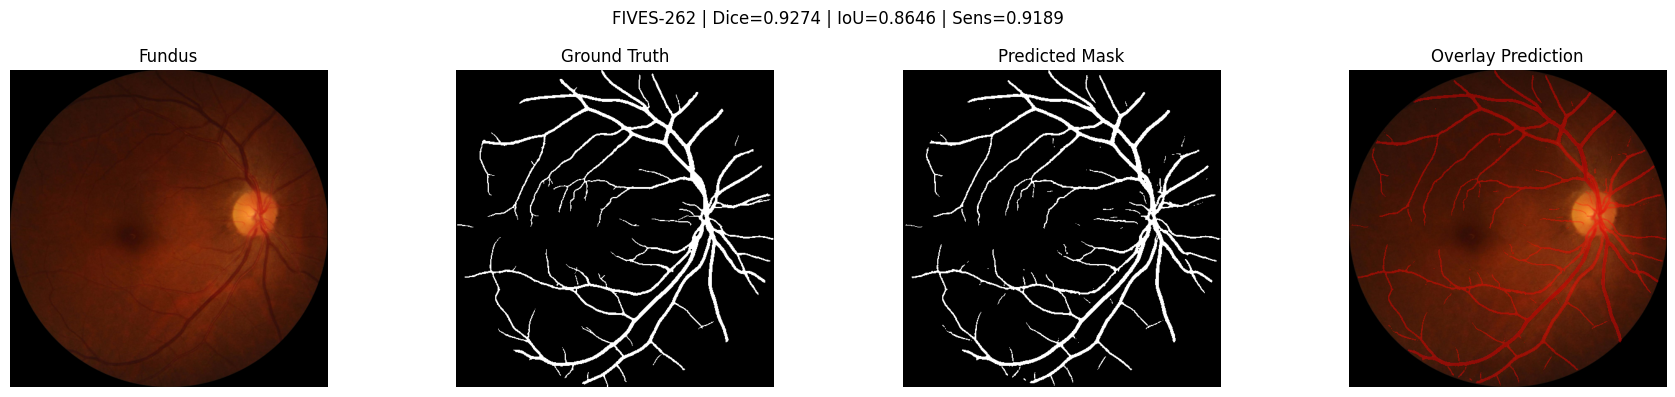

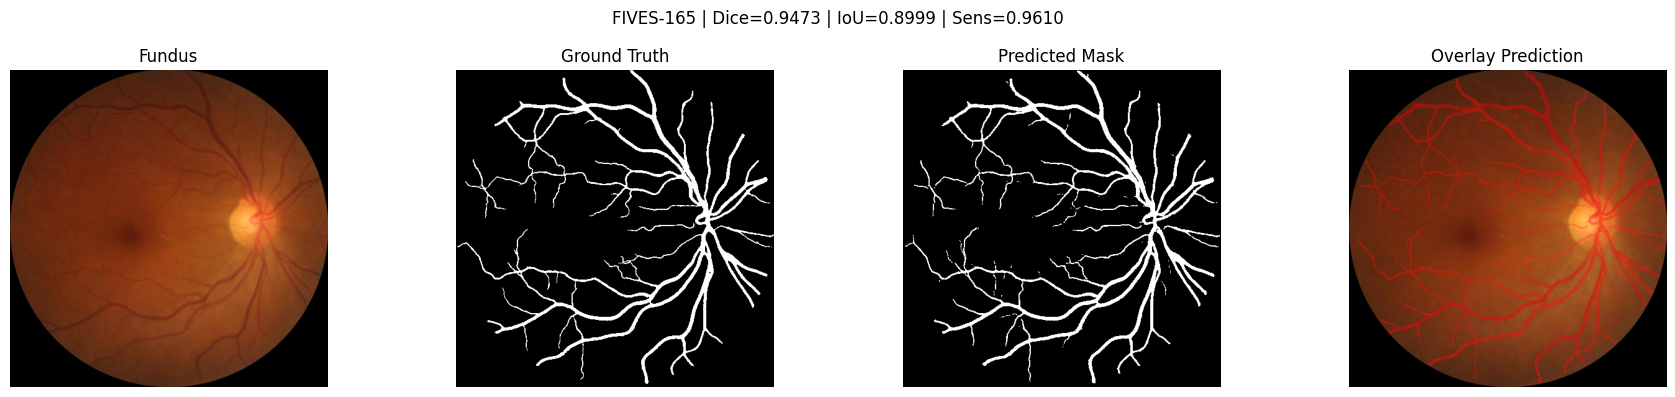

Preview training disimpan di: /content/drive/MyDrive/BV_CDR/results/previews/training_fives


In [ ]:
# ============================================================
# 21. Preview hasil prediksi: image, ground truth, prediksi, overlay
# ============================================================
preview_samples = per_image_df.sample(n=min(5, len(per_image_df)), random_state=RANDOM_SEED)

for _, row in preview_samples.iterrows():
    image_np = load_image_np(row['image_path'])
    true_mask = load_mask_np(row['gt_mask_path'])
    pred_mask = np.array(Image.open(row['pred_mask_path']).convert('L')) > 127
    overlay = np.array(Image.open(row['overlay_path']).convert('RGB'))

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    axes[0].imshow(image_np)
    axes[0].set_title('Fundus')
    axes[0].axis('off')

    axes[1].imshow(true_mask, cmap='gray')
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')

    axes[2].imshow(pred_mask, cmap='gray')
    axes[2].set_title('Predicted Mask')
    axes[2].axis('off')

    axes[3].imshow(overlay)
    axes[3].set_title('Overlay Prediction')
    axes[3].axis('off')

    title = f"{row['filename']} | Dice={row['dice']:.4f} | IoU={row['iou']:.4f} | Sens={row['recall_sensitivity']:.4f}"
    plt.suptitle(title)
    plt.tight_layout()

    save_path = PREVIEW_DIR / f"preview_pred_{row['filename']}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print('Preview training disimpan di:', PREVIEW_DIR)


In [ ]:
# ============================================================
# 22. Simpan ringkasan konfigurasi training
# ============================================================
training_summary = {
    'base_dir': str(BASE_DIR),
    'csv_path': str(CSV_PATH),
    'model_type': MODEL_TYPE,
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs_configured': EPOCHS,
    'epochs_trained': len(history_df),
    'learning_rate_initial': LEARNING_RATE,
    'threshold': THRESHOLD,
    'train_count': len(train_df),
    'val_count': len(val_df),
    'test_count': len(test_df),
    'best_model_path': str(BEST_MODEL_PATH),
    'last_model_path': str(LAST_MODEL_PATH),
    'history_csv': str(HISTORY_CSV_PATH),
    'test_metrics_csv': str(TEST_METRICS_CSV_PATH),
    'per_image_metrics_csv': str(PER_IMAGE_METRICS_CSV_PATH),
    'pred_mask_dir': str(PRED_MASK_DIR),
    'overlay_dir': str(PRED_OVERLAY_DIR),
}

summary_json_path = METRICS_DIR / f'training_summary_{MODEL_TYPE}_fives.json'
summary_csv_path = METRICS_DIR / f'training_summary_{MODEL_TYPE}_fives.csv'

with open(summary_json_path, 'w') as f:
    json.dump(training_summary, f, indent=4)

pd.DataFrame([training_summary]).to_csv(summary_csv_path, index=False)

display(pd.DataFrame([training_summary]))
print('Training summary JSON:', summary_json_path)
print('Training summary CSV :', summary_csv_path)


,base_dir,csv_path,model_type,img_size,batch_size,epochs_configured,epochs_trained,learning_rate_initial,threshold,train_count,val_count,test_count,best_model_path,last_model_path,history_csv,test_metrics_csv,per_image_metrics_csv,pred_mask_dir,overlay_dir
0,/content/drive/MyDrive/BV_CDR,/content/drive/MyDrive/BV_CDR/splits/processed...,unet,512,4,50,50,0.0001,0.5,279,60,61,/content/drive/MyDrive/BV_CDR/models/unet/best...,/content/drive/MyDrive/BV_CDR/models/unet/last...,/content/drive/MyDrive/BV_CDR/results/metrics/...,/content/drive/MyDrive/BV_CDR/results/metrics/...,/content/drive/MyDrive/BV_CDR/results/metrics/...,/content/drive/MyDrive/BV_CDR/predictions/five...,/content/drive/MyDrive/BV_CDR/predictions/five...


Training summary JSON: /content/drive/MyDrive/BV_CDR/results/metrics/training_summary_unet_fives.json
Training summary CSV : /content/drive/MyDrive/BV_CDR/results/metrics/training_summary_unet_fives.csv


# Setelah notebook training selesai

File penting yang akan dipakai untuk tahap berikutnya:

```text
/content/drive/MyDrive/BV_CDR/models/unet/best_unet_fives.keras
```

Hasil prediksi vessel pada test set FIVES tersimpan di:

```text
/content/drive/MyDrive/BV_CDR/predictions/fives_test/masks_pred/
/content/drive/MyDrive/BV_CDR/predictions/fives_test/overlay/
```

Tahap berikutnya adalah membuat notebook **inference ke REFUGE**, yaitu memakai model vessel FIVES ini untuk menghasilkan:

```text
REFUGE fundus image → predicted blood vessel mask
```

Hasil predicted mask REFUGE nanti akan dipakai sebagai salah satu input fusion bersama ROI CDR/cup-disc.
